<a href="https://colab.research.google.com/github/Alafiade/Digital-Path/blob/main/OPEN_SLIDE_LIBRARY_FOR_WHOLE_SLIDE_IMAGES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTALLING LIBRARIES

In [1]:
!pip install openslide-python

In [2]:
! apt-get install openslide-tools

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 0s (1,679 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Selecting previously unselected package openslide-tools

In [3]:
import openslide

In [4]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

DOWNLOADING WSI DATA FROM HUGGING FACE

In [5]:
from huggingface_hub import hf_hub_download

slide = hf_hub_download(
    "rendeirolab/lazyslide-data",
    "GTEX-1117F-0526.svs",
    repo_type = "dataset",
    cache_dir = "."

)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


GTEX-1117F-0526.svs:   0%|          | 0.00/37.3M [00:00<?, ?B/s]

In [6]:
#Wrapping our data in Openslide object to handle massive file sizes
slide_object = openslide.OpenSlide(slide)

# Viewing the WSIs properties
slide_props = slide_object.properties

PRINTING THE PROPERTIES OF OUR WHOLE SLIDE IMAGES

In [7]:
slide_props

<_PropertyMap {'aperio.AppMag': '20', 'aperio.DSR ID': 'vaiaperio03', 'aperio.Date': '05/08/13', 'aperio.DisplayColor': '0', 'aperio.Exposure Scale': '0.000001', 'aperio.Exposure Time': '109', 'aperio.Filename': '2063440', 'aperio.Focus Offset': '-0.000500', 'aperio.ICC Profile': 'ScanScope v1', 'aperio.ImageID': '46695', 'aperio.Left': '18.570766', 'aperio.LineAreaXOffset': '0.023001', 'aperio.LineAreaYOffset': '-0.006920', 'aperio.LineCameraSkew': '0.001659', 'aperio.MPP': '0.4942', 'aperio.OriginalHeight': '20058', 'aperio.OriginalWidth': '20320', 'aperio.ScanScope ID': 'SS1553', 'aperio.StripeWidth': '2032', 'aperio.Time': '10:36:40', 'aperio.Time Zone': 'GMT-04:00', 'aperio.Top': '14.799458', 'aperio.User': 'b10ddf97-9ed8-4e11-909e-3825a7cfa9e2', 'openslide.comment': 'Aperio Image Library v12.0.11 \r\n20320x20058 [0,100 19919x19958] (240x240) JPEG/RGB Q=70|AppMag = 20|StripeWidth = 2032|ScanScope ID = SS1553|Filename = 2063440|Date = 05/08/13|Time = 10:36:40|Time Zone = GMT-04:00|

In [8]:
print("Vendor is:",slide_props['openslide.vendor'])

Vendor is: aperio


In [9]:
print("Pixel  size of X  in um is:",slide_props["openslide.mpp-x"])
print("Pixel size of Y in um is:", slide_props["openslide.mpp-y"])

Pixel  size of X  in um is: 0.49419999999999997
Pixel size of Y in um is: 0.49419999999999997


In [10]:
#Displaying the native resolution of the Whole Slide Image
slide_dims = slide_object.dimensions
print(slide_dims)

(19919, 19958)


In [11]:
slide_thumb_256 = slide_object.get_thumbnail(size=(256,256))
slide_thumb_256.show()

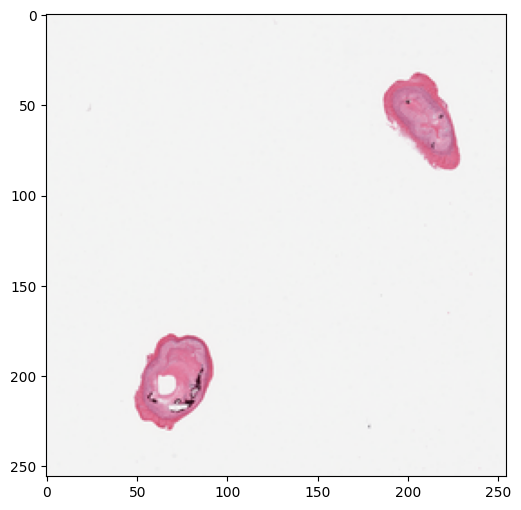

In [12]:
slide_thumb_256_np = np.array(slide_thumb_256)
plt.figure(figsize=(6,6))
plt.imshow(slide_thumb_256_np)


In [13]:
#Whole Slide Images have a pyramidial structure
# slide.level_dimensions displays the pyramidial levels

dims = slide_object.level_dimensions
dims

((19919, 19958), (4979, 4989), (2489, 2494))

In [14]:
num_levels = len(dims)
print("The levels of WSI images are:",num_levels)

The levels of WSI images are: 3


In [15]:
# Assessing the Levels of the WSI images using indexing

level_3_dims = dims[2]
level_3_dims

(2489, 2494)

In [16]:
# Scaling factor of the WSI image
# This code displays how much each level in the WSI is scaled down

factors = slide_object.level_downsamples
print('Each level is downsampled by an amount of: ',factors)

Each level is downsampled by an amount of:  (1.0, 4.000501706284455, 8.002609074152414)


In [17]:
# This reads the topleft image of the third level in the WSI

level_3_dims = dims[2]
level_3_img = slide_object.read_region((0,0),2, level_3_dims)

In [18]:
#Converting the PIL image from RGBA to RGB for analysis
level_3_img_RGB = level_3_img.convert('RGB')
level_3_img_RGB.show()

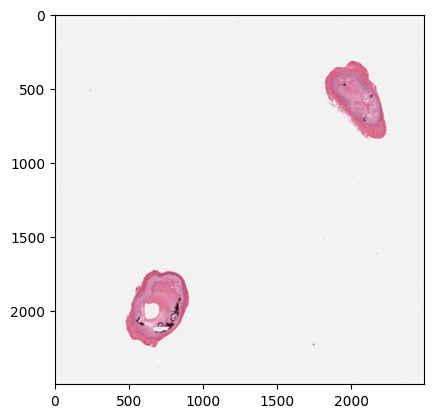

In [19]:
level_3_img_np = np.array(level_3_img_RGB)
plt.imshow(level_3_img_np)

Due to WSI's large image file, the Images are downsampled  relative to the highest resolution (level0)

In [20]:
#This downsamples the original image resolution to a factor of 32
SCALE_FACTOR = 32
#This picks the best level closest to a scaled down factor of 32
best_level = slide_object.get_best_level_for_downsample(SCALE_FACTOR)

In [21]:
best_level

2

In [23]:
 from openslide.deepzoom import DeepZoomGenerator

In [24]:
#This splits our WSI into tiles of 256x256pixels
tiles = DeepZoomGenerator(slide_object, tile_size=256, overlap=0, limit_bounds = False)

In [25]:
print("The number of levels in our tiles are:", tiles.level_count)

The number of levels in our tiles are: 16


In [26]:
print("The dimensions of data in each level are:", tiles.level_dimensions)

The dimensions of data in each level are: ((1, 1), (2, 2), (3, 3), (5, 5), (10, 10), (20, 20), (39, 39), (78, 78), (156, 156), (312, 312), (623, 624), (1245, 1248), (2490, 2495), (4980, 4990), (9960, 9979), (19919, 19958))


In [27]:
print("Toal number of tiles:",tiles.tile_count)

Toal number of tiles: 8152


In [30]:
#Inspecting the Tile shape at each level
level_num = 11
print("Tiles shape at level", level_num,"is:", tiles.level_tiles[level_num])
print("This means there are", tiles.level_tiles[level_num][0],"tiles.level_tiles")

Tiles shape at level 11 is: (5, 5)
This means there are 5 tiles.level_tiles


In [37]:
tile_dims = tiles.get_tile_dimensions(11,(0,3))
tile_dims

(256, 256)

In [41]:
#Counting the number of tiles in the level 16
level_num = 15
tile_count_in_large_image = tiles.level_tiles[level_num]
print(tile_count_in_large_image)

(78, 78)


In [48]:
#Displaying the tile dimensions

tile_dims_in_large_image = tiles.get_tile_dimensions(15,(77,77))
tile_dims_in_large_image

(207, 246)

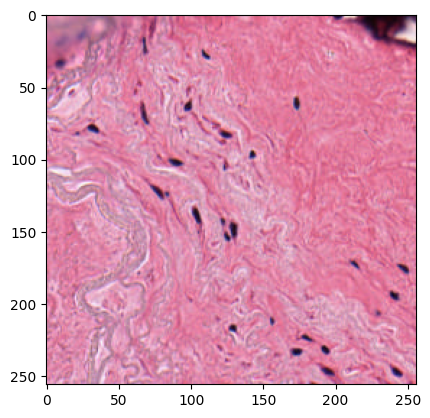

In [58]:
# Visualizing/Displaying a single tile from their dimensions

single_tile = tiles.get_tile(15,(60,15))
single_tile_RGB = single_tile.convert('RGB')
single_tile_np = np.array(single_tile_RGB)
plt.imshow(single_tile_np)
plt.show()

In [59]:
# Saving Tiles level to hard disk for preprocessing
cols, rows = tiles.level_tiles[15]

import os

tile_dir  = '/content/WSI level 0 sllide  tiles'
for row in range(rows):
  for col in range(cols):
    tile_name = os.path.join(tile_dir,"%d_%d"% (col,row))
    print("Now saving tile with tile:", tile_name)
    temp_tile = tiles.get_tile(15, (col, row))
    temp_tile_RGB = temp_tile.convert('RGB')
    temp_tile_np = np.array(temp_tile_RGB)
    plt.imsave(tile_name + ".png", temp_tile_np)



Streaming output truncated to the last 5000 lines.
Now saving tile with tile: /content/WSI level 0 sllide  tiles/70_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/71_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/72_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/73_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/74_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/75_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/76_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/77_13
Now saving tile with tile: /content/WSI level 0 sllide  tiles/0_14
Now saving tile with tile: /content/WSI level 0 sllide  tiles/1_14
Now saving tile with tile: /content/WSI level 0 sllide  tiles/2_14
Now saving tile with tile: /content/WSI level 0 sllide  tiles/3_14
Now saving tile with tile: /content/WSI level 0 sllide  tiles/4_14
Now saving tile with tile: /content/WSI level 0 sllide  tiles/5_14
Now